# OpenMC transport model for the frm2 geometry using natural uranium

 ## Models

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc

from fuel_element import build_fuel_element_model, quick_layout_plot
from involutes import InvoluteElementParameters, build_parameter_report, spiral_summary, validate_parameters
from reactor_geometry import (
    ReactorTankParameters,
    build_reactor_model,
    validate_reactor_tanks,
    )

FUEL_ELEMENT_PARAMETERS = InvoluteElementParameters(
    plate_count=25,
    plate_thickness_cm=2.0,
    coolant_gap_cm=2.0,
    inner_radius_cm=20.0,
    outer_radius_cm=50.0,
    control_rod_radius_cm=4.0,
    h_active_cm=200.0,
    lower_plenum_cm=50.0,
    upper_plenum_cm=50.0,
    segments_per_plate=24,
    base_radius_cm=18.0,
 )

REACTOR_TANK_PARAMETERS = ReactorTankParameters(
    d2o_tank_radius_cm=200.0,
    h2o_tank_radius_cm=400.0,
    h_d2o_tank_cm=500.0,
    h_h2o_tank_cm=800.0,
 )

validate_parameters(FUEL_ELEMENT_PARAMETERS)
validate_reactor_tanks(FUEL_ELEMENT_PARAMETERS, REACTOR_TANK_PARAMETERS)

GEOMETRY = build_parameter_report(FUEL_ELEMENT_PARAMETERS)
GEOMETRY.update(REACTOR_TANK_PARAMETERS.to_geometry_dict())
GEOMETRY["mesh_x_bins"] = 500
GEOMETRY["mesh_z_bins"] = 500

BUILD_DIR = Path("build") / "notebook"
for build_path in (BUILD_DIR / "fuel_element", BUILD_DIR / "reactor"):
    build_path.mkdir(parents=True, exist_ok=True)

In [6]:
def build_model(rod_insertion=0.0, particles=12000, batches=100, inactive=20):
    rod_insertion = float(np.clip(rod_insertion, 0.0, 1.0))
    model, metadata = build_reactor_model(
        FUEL_ELEMENT_PARAMETERS,
        REACTOR_TANK_PARAMETERS,
        rod_insertion=rod_insertion,
    )

    total_half = 0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm
    active_half = 0.5 * FUEL_ELEMENT_PARAMETERS.h_active_cm

    source = openmc.IndependentSource(
        space=openmc.stats.Box(
            (-FUEL_ELEMENT_PARAMETERS.outer_radius_cm, -FUEL_ELEMENT_PARAMETERS.outer_radius_cm, -active_half),
            (FUEL_ELEMENT_PARAMETERS.outer_radius_cm, FUEL_ELEMENT_PARAMETERS.outer_radius_cm, active_half),
        ),
        constraints={"fissionable": True},
    )

    settings = openmc.Settings()
    settings.run_mode = "eigenvalue"
    settings.particles = particles
    settings.batches = batches
    settings.inactive = inactive
    settings.source = source
    settings.temperature = {"method": "interpolation"}
    model.settings = settings

    mesh = openmc.RegularMesh()
    mesh.dimension = (GEOMETRY["mesh_x_bins"], 1, GEOMETRY["mesh_z_bins"])
    mesh.lower_left = (-REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm, -1.0, -total_half)
    mesh.upper_right = (REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm, 1.0, total_half)

    tally = openmc.Tally(name="core-mesh")
    tally.filters = [openmc.MeshFilter(mesh)]
    tally.scores = ["flux", "fission", "nu-fission"]
    model.tallies = openmc.Tallies([tally])

    metadata["mesh_shape"] = tuple(mesh.dimension)
    return model, metadata

{'plate_count': 25, 'base_radius_cm': 18.0, 'theta_inner': np.float64(0.48432210483785276), 'theta_outer': np.float64(2.5915341754868), 'single_plate_length_cm': np.float64(70.86712351771415), 'uranium_area_fraction': np.float64(0.5370882385975292)}


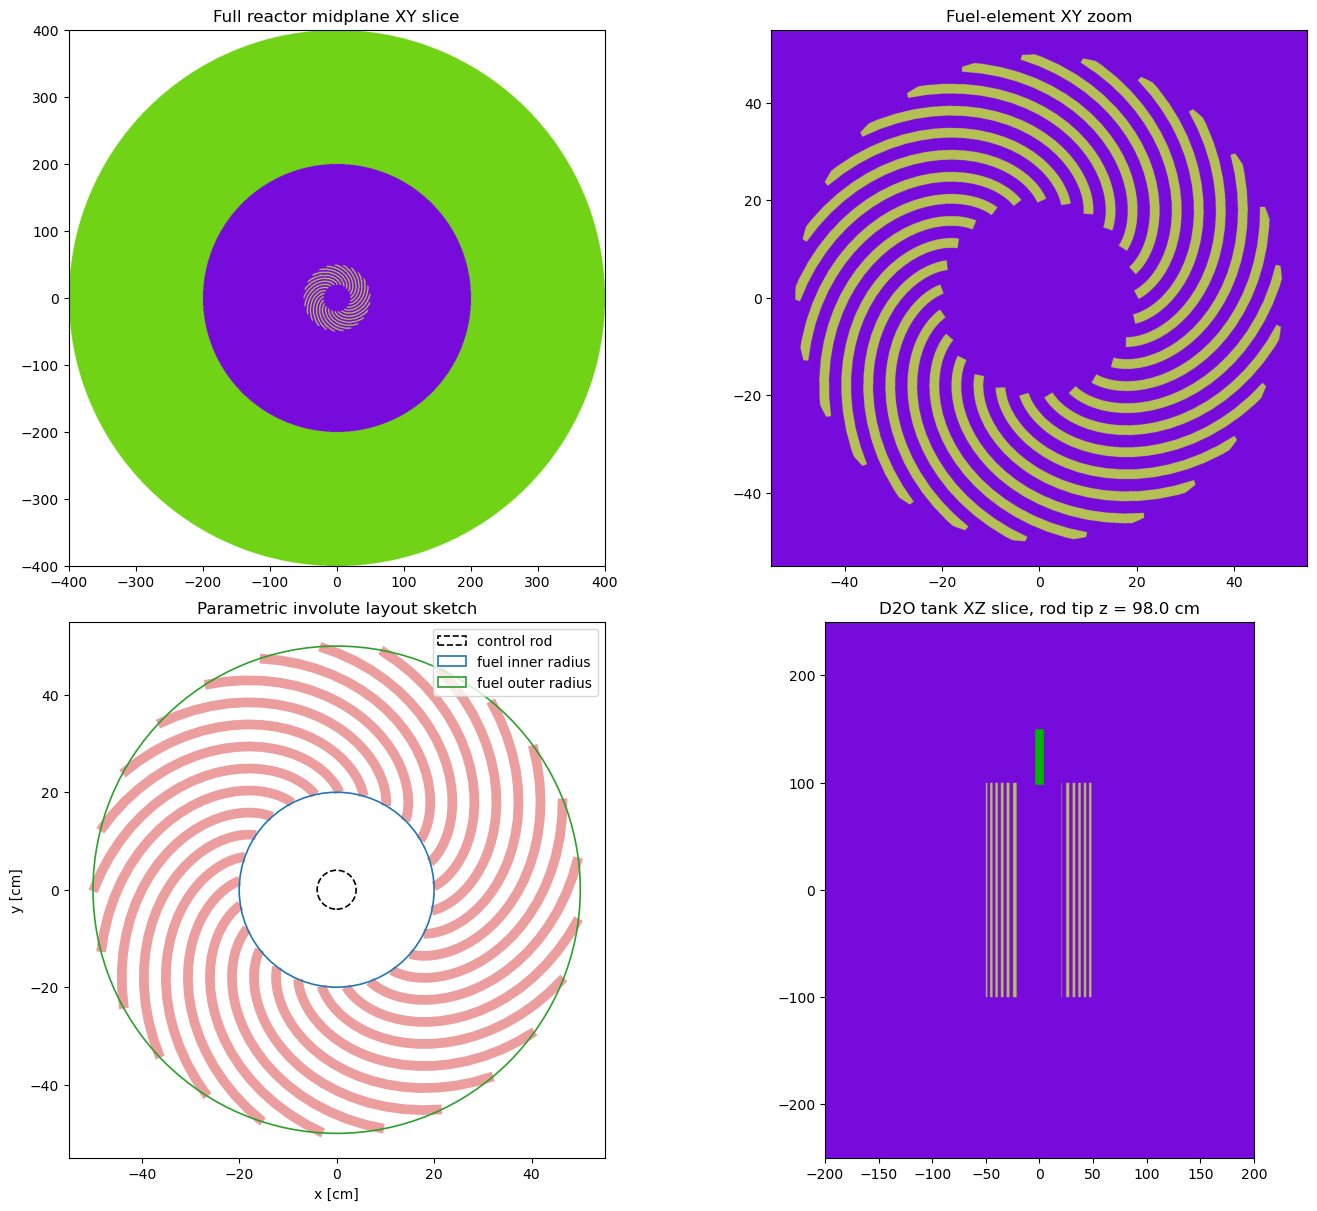

In [7]:
preview_model, preview_metadata = build_model(rod_insertion=0.01, particles=2000, batches=20, inactive=5)

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.0 * REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
        2.0 * REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
    ),
    basis="xy",
    color_by="material",
    pixels=(1200, 1200),
    axes=axes[0, 0],
)
axes[0, 0].set_title("Full reactor midplane XY slice")

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.2 * FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
        2.2 * FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
    ),
    basis="xy",
    color_by="material",
    pixels=(2200, 2200),
    axes=axes[0, 1],
)
axes[0, 1].set_title("Fuel-element XY zoom")

quick_layout_plot(FUEL_ELEMENT_PARAMETERS, ax=axes[1, 0])
axes[1, 0].set_title("Parametric involute layout sketch")

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.0 * REACTOR_TANK_PARAMETERS.d2o_tank_radius_cm,
        REACTOR_TANK_PARAMETERS.h_d2o_tank_cm,
    ),
    basis="xz",
    color_by="material",
    pixels=(1800, 1600),
    axes=axes[1, 1],
)
axes[1, 1].set_title(f"D2O tank XZ slice, rod tip z = {preview_metadata['fuel_element']['rod_tip_z_cm']:.1f} cm")

print(spiral_summary(FUEL_ELEMENT_PARAMETERS))
plt.show()

In [ ]:
cross_sections = openmc.config.get("cross_sections")

if cross_sections:
    reference_insertion = 0.0
    reference_model, reference_metadata = build_model(
        rod_insertion=reference_insertion,
        particles=16000,
        batches=1,
        inactive=0,
    )
    statepoint_path = reference_model.run()
    print(f"OpenMC run finished: {statepoint_path}")
else:
    statepoint_path = None
    reference_metadata = None
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before running eigenvalue calculations."
    )

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

k_eff = 0.633979 +/- inf
reactivity = -57733.8 pcm


/home/pablo/miniconda3/envs/openmc/lib/python3.13/site-packages/openmc/tallies.py:549: RuntimeWarning: invalid value encountered in divide
  self._std_dev[nonzero] = np.sqrt((self.sum_sq[nonzero]/n -


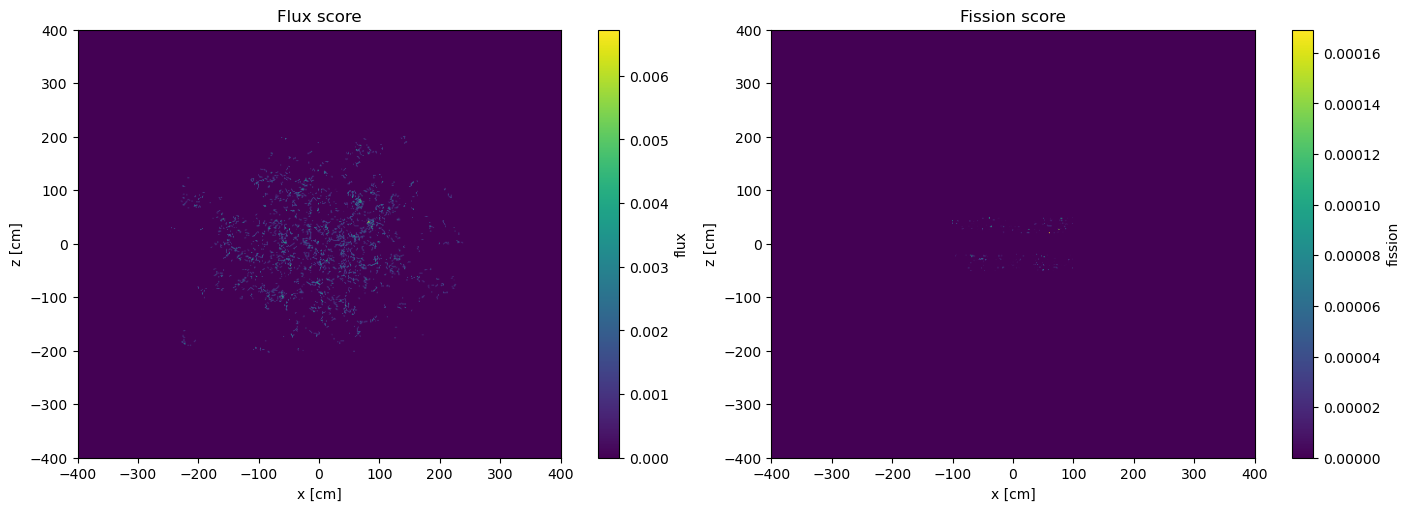

In [12]:
try:
    with openmc.StatePoint(statepoint_path) as statepoint:
        keff = statepoint.keff
        rho_pcm = (keff.n - 1.0) / keff.n * 1.0e5
        print(f"k_eff = {keff.n:.6f} +/- {keff.s:.6f}")
        print(f"reactivity = {rho_pcm:.1f} pcm")

        mesh_tally = statepoint.get_tally(name="core-mesh")
        flux_tally = mesh_tally.get_slice(scores=["flux"])
        fission_tally = mesh_tally.get_slice(scores=["fission"])
        mesh_shape = reference_metadata["mesh_shape"] if reference_metadata is not None else tuple(mesh_tally.filters[0].mesh.dimension)
        flux = flux_tally.get_reshaped_data(value="mean").reshape(mesh_shape).squeeze()
        fission = fission_tally.get_reshaped_data(value="mean").reshape(mesh_shape).squeeze()
        extent = [
            -REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
            REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
            -0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm,
            0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm,
        ]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
        flux_image = axes[0].imshow(
            flux.T,
            origin="lower",
            aspect="auto",
            extent=extent,
        )
        axes[0].set_xlabel("x [cm]")
        axes[0].set_ylabel("z [cm]")
        axes[0].set_title("Flux score")
        plt.colorbar(flux_image, ax=axes[0], label="flux")

        fission_image = axes[1].imshow(
            fission.T,
            origin="lower",
            aspect="auto",
            extent=extent,
        )
        axes[1].set_xlabel("x [cm]")
        axes[1].set_ylabel("z [cm]")
        axes[1].set_title("Fission score")
        plt.colorbar(fission_image, ax=axes[1], label="fission")
        plt.show()
except (FileNotFoundError, NameError, TypeError):
    print("Run the previous cell after configuring OpenMC nuclear data to get flux and fission maps.")

In [ ]:
try:
    with openmc.StatePoint(statepoint_path) as statepoint:
        keff = statepoint.keff
        rho_pcm = (keff.n - 1.0) / keff.n * 1.0e5
        print(f"k_eff = {keff.n:.6f} +/- {keff.s:.6f}")
        print(f"reactivity = {rho_pcm:.1f} pcm")

        mesh_tally = statepoint.get_tally(name="core-mesh")
        flux_tally = mesh_tally.get_slice(scores=["flux"])
        fission_tally = mesh_tally.get_slice(scores=["fission"])
        mesh_shape = tuple(mesh_tally.filters[0].mesh.dimension)
        flux = flux_tally.get_reshaped_data(value="mean").reshape(mesh_shape).squeeze()
        fission = fission_tally.get_reshaped_data(value="mean").reshape(mesh_shape).squeeze()
        extent = [
            -GEOMETRY["h2o_tank_radius_cm"],
            GEOMETRY["h2o_tank_radius_cm"],
            -0.5 * GEOMETRY["h_total_cm"],
            0.5 * GEOMETRY["h_total_cm"],
        ]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
        flux_image = axes[0].imshow(
            flux.T,
            origin="lower",
            aspect="auto",
            extent=extent,
        )
        axes[0].set_xlabel("x [cm]")
        axes[0].set_ylabel("z [cm]")
        axes[0].set_title("Flux score")
        plt.colorbar(flux_image, ax=axes[0], label="flux")

        fission_image = axes[1].imshow(
            fission.T,
            origin="lower",
            aspect="auto",
            extent=extent,
        )
        axes[1].set_xlabel("x [cm]")
        axes[1].set_ylabel("z [cm]")
        axes[1].set_title("Fission score")
        plt.colorbar(fission_image, ax=axes[1], label="fission")
        plt.show()
except (FileNotFoundError, NameError, TypeError):
    print("Run the previous cell after configuring OpenMC nuclear data to get flux and fission maps.")